# CropShield AI — ML Learning Notebook

This notebook is our learning and experimentation area for CropShield AI.

We will:
1. Load the agricultural datasets.
2. Understand and explore the data.
3. Calculate crop risk.
4. Prepare data for Machine Learning.
5. Train and evaluate a model.
6. Test the model with new agricultural conditions.

In [3]:
import pandas as pd

master_df = pd.read_csv(
    r"D:\AGRI_RAKSHAK\data\CropShield_Master_2026_MVP (1).csv"
)

master_df.head()

,Year,Date,District,Crop,Season,Rainfall_mm,Soil_Moisture_Percent,Area_hectare,Production_tonnes,Yield_tonnes_per_hectare
0,2026,2026-08-19,Ahmednagar,Maize,Kharif,23.8,34.04,97529,265278.88,2.72
1,2026,2026-08-20,Ahmednagar,Maize,Kharif,28.1,32.83,97529,265278.88,2.72
2,2026,2026-08-21,Ahmednagar,Maize,Kharif,25.1,34.34,97529,265278.88,2.72
3,2026,2026-08-22,Ahmednagar,Maize,Kharif,25.8,32.69,97529,265278.88,2.72
4,2026,2026-08-23,Ahmednagar,Maize,Kharif,34.6,33.50,97529,265278.88,2.72


In [4]:
master_df.shape

(2240, 10)

In [5]:
master_df.columns

Index(['Year', 'Date', 'District', 'Crop', 'Season', 'Rainfall_mm',
       'Soil_Moisture_Percent', 'Area_hectare', 'Production_tonnes',
       'Yield_tonnes_per_hectare'],
      dtype='str')

master_df.info()

## Exploring Categorical Data

Before building a Machine Learning model, we need to understand
the categories present in our dataset.

We will check:

- How many districts are present.
- Which districts are present.
- How many different crops are present.
- Which crops are present.
- Which growing seasons are present.

This helps us understand the variety of agricultural conditions
represented in our dataset.

In [8]:
print("Number of districts:", master_df["District"].nunique())
print("Districts:", master_df["District"].unique())

print("\nNumber of crops:", master_df["Crop"].nunique())
print("Crops:", master_df["Crop"].unique())

print("\nSeasons:", master_df["Season"].unique())

Number of districts: 35
Districts: <StringArray>
['Ahmednagar',      'Akola',   'Amravati', 'Aurangabad',   'Bhandara',
       'Beed',   'Buldhana', 'Chandrapur',      'Dhule', 'Gadchiroli',
     'Gondia',    'Hingoli',    'Jalgaon',      'Jalna',   'Kolhapur',
      'Latur',     'Mumbai',     'Nagpur',     'Nanded',  'Nandurbar',
     'Nashik',  'Osmanabad',    'Palghar',   'Parbhani',       'Pune',
     'Raigad',  'Ratnagiri',     'Sangli',     'Satara', 'Sindhudurg',
    'Solapur',      'Thane',     'Wardha',     'Washim',   'Yavatmal']
Length: 35, dtype: str

Number of crops: 4
Crops: <StringArray>
['Maize', 'Soybean', 'Cotton', 'Sugarcane']
Length: 4, dtype: str

Seasons: <StringArray>
['Kharif']
Length: 1, dtype: str


## Exploring Numerical Data

Now we will examine the numerical columns in our dataset.

These columns contain measurements that can influence crop conditions:

- Rainfall_mm — daily rainfall in millimetres.
- Soil_Moisture_Percent — percentage of moisture in the soil.
- Area_hectare — cultivated area.
- Production_tonnes — crop production.
- Yield_tonnes_per_hectare — crop yield.

The `describe()` function gives us statistical information such as
the minimum, maximum, average (mean), and quartiles.

This helps us identify whether the values look reasonable before
using the data for risk analysis and Machine Learning.

In [9]:
master_df.describe()

,Year,Rainfall_mm,Soil_Moisture_Percent,Area_hectare,Production_tonnes,Yield_tonnes_per_hectare
count,2240.0,2240.000000,2240.000000,2240.000000,2.240000e+03,2240.000000
mean,2026.0,16.934777,27.755661,163113.607143,1.634219e+06,21.628857
std,0.0,15.456342,7.769471,92503.397655,2.517989e+06,34.815558
min,2026.0,0.000000,12.000000,49818.000000,8.419236e+04,0.410000
25%,2026.0,3.300000,21.390000,82910.250000,1.811230e+05,1.000000
50%,2026.0,14.000000,27.640000,141516.000000,2.666868e+05,2.075000
75%,2026.0,24.225000,33.695000,232059.000000,1.300218e+06,21.157500
max,2026.0,59.900000,46.120000,362239.000000,8.196881e+06,90.140000


In [10]:
master_df["Date"] = pd.to_datetime(master_df["Date"])

master_df["Date"].head()

0   2026-08-19
1   2026-08-20
2   2026-08-21
3   2026-08-22
4   2026-08-23
Name: Date, dtype: datetime64[us]

## Examining Rainfall and Soil Moisture

Rainfall and soil moisture are two important environmental
variables for crop health.

Rainfall provides water to the agricultural land, while soil
moisture tells us how much water is currently available in the soil.

We will first look at a few rows containing these two variables.

This is not Machine Learning yet. We are simply trying to understand
the relationship between the environmental conditions in our dataset.

In [11]:
master_df[["Date", "District", "Crop", "Rainfall_mm", "Soil_Moisture_Percent"]].head(10)

,Date,District,Crop,Rainfall_mm,Soil_Moisture_Percent
0,2026-08-19,Ahmednagar,Maize,23.8,34.04
1,2026-08-20,Ahmednagar,Maize,28.1,32.83
2,2026-08-21,Ahmednagar,Maize,25.1,34.34
3,2026-08-22,Ahmednagar,Maize,25.8,32.69
4,2026-08-23,Ahmednagar,Maize,34.6,33.50
5,2026-08-24,Ahmednagar,Maize,22.9,29.60
6,2026-08-25,Ahmednagar,Maize,1.7,30.75
7,2026-08-26,Ahmednagar,Maize,31.8,31.17
8,2026-08-27,Ahmednagar,Maize,17.0,29.96
9,2026-08-28,Ahmednagar,Maize,25.6,30.93


## Measuring the Relationship Between Rainfall and Soil Moisture

We will calculate the correlation between rainfall and soil moisture.

Correlation measures how strongly two numerical variables move
together.

The correlation value ranges from -1 to +1:

- +1 → strong positive relationship
- 0 → little or no linear relationship
- -1 → strong negative relationship

A positive correlation would mean that higher rainfall tends to be
associated with higher soil moisture in our dataset.

This is an exploratory analysis. Correlation does not mean that one
variable necessarily causes the other.

In [12]:
correlation = master_df["Rainfall_mm"].corr(
    master_df["Soil_Moisture_Percent"]
)

print("Rainfall–Soil Moisture correlation:", correlation)

Rainfall–Soil Moisture correlation: -0.019292210700277694


### Observation

The correlation between rainfall and soil moisture in our synthetic
dataset is approximately -0.019.

This is very close to zero, meaning there is almost no linear
relationship between the two variables in this dataset.

This reminds us that synthetic data may not perfectly represent
real-world agricultural relationships. Therefore, we should inspect
and validate our data before building the CropShield risk model.

## Understanding Crop Risk Conditions

Crop risk can be influenced by environmental conditions such as
rainfall and soil moisture.

For our CropShield prototype, we will initially focus on these
environmental variables to create a simple rule-based risk score.

This rule-based score is not yet Machine Learning.

It will act as a learning tool to help us understand how input
conditions can be converted into a risk value.

Later, we can use Machine Learning to learn patterns from the data
and compare the ML predictions with this rule-based approach.

## Comparing Environmental Conditions by Crop

Different crops can have different environmental requirements.

Before creating a risk score, we will compare the average rainfall
and soil moisture values for each crop.

This helps us understand whether our dataset contains different
environmental patterns for Maize, Soybean, Cotton, and Sugarcane.

We will use `groupby()` to group the observations by crop and then
calculate the average rainfall and soil moisture for each group.

In [13]:
crop_conditions = (
    master_df
    .groupby("Crop")[["Rainfall_mm", "Soil_Moisture_Percent"]]
    .mean()
    .round(2)
)

crop_conditions

,Rainfall_mm,Soil_Moisture_Percent
Crop,,
Cotton,16.87,27.76
Maize,16.12,27.76
Soybean,17.19,27.76
Sugarcane,17.57,27.76


## Checking Soil Moisture Variation Over Time

The previous analysis showed that the average soil moisture is the
same for every crop.

Now we will check whether soil moisture changes across different
dates.

This is important because CropShield is intended to work with
changing environmental conditions.

If soil moisture changes over time, the model may still be able to
use it as an environmental feature even though it does not differ
between crops.

In [14]:
daily_moisture = (
    master_df
    .groupby("Date")["Soil_Moisture_Percent"]
    .mean()
    .round(2)
)

daily_moisture

Date
2026-08-19    28.21
2026-08-20    27.85
2026-08-21    28.38
2026-08-22    27.57
2026-08-23    28.07
2026-08-24    27.46
2026-08-25    27.98
2026-08-26    27.66
2026-08-27    27.83
2026-08-28    27.58
2026-08-29    27.96
2026-08-30    27.89
2026-08-31    27.87
2026-09-01    27.18
2026-09-02    27.49
2026-09-03    27.10
Name: Soil_Moisture_Percent, dtype: float64

## Observation: Soil Moisture Over Time

The daily average soil moisture changes over the 16-day period,
but the variation is relatively small.

The minimum daily average is approximately 27.10%, while the maximum
is approximately 28.38%.

This means soil moisture provides some variation for analysis, but
the synthetic dataset does not represent large real-world changes
in soil moisture.

Therefore, the CropShield MVP risk model should be treated as a
prototype and not as an agronomic recommendation system.

## Examining Daily Rainfall

We will calculate the average rainfall for each date.

This allows us to see how rainfall changes during the period covered
by our dataset.

Understanding this variation is important because unusual rainfall
conditions may contribute to agricultural risk.

In [15]:
daily_rainfall = (
    master_df
    .groupby("Date")["Rainfall_mm"]
    .mean()
    .round(2)
)

daily_rainfall

Date
2026-08-19    16.21
2026-08-20    17.93
2026-08-21    17.33
2026-08-22    16.90
2026-08-23    17.23
2026-08-24    16.13
2026-08-25    15.20
2026-08-26    19.60
2026-08-27    15.44
2026-08-28    14.73
2026-08-29    17.72
2026-08-30    16.08
2026-08-31    18.19
2026-09-01    17.31
2026-09-02    19.60
2026-09-03    15.36
Name: Rainfall_mm, dtype: float64

## Observation: Rainfall Over Time

The daily average rainfall in our synthetic dataset ranges from
approximately 14.73 mm to 19.60 mm.

The rainfall changes from day to day, but there are no extremely
high or low rainfall values during this period.

This gives us some variation for building our prototype risk model,
but the dataset may not represent the full range of real-world
rainfall conditions.

Therefore, rainfall should be used carefully when creating our
CropShield AI risk score.

## Building a Prototype Risk Score

Before using Machine Learning, we will create a simple rule-based
risk score.

The purpose is to understand how input conditions can be converted
into a measurable risk value.

For this prototype, we consider two environmental factors:

1. Rainfall
2. Soil moisture

Potential risk conditions include:

- Low rainfall → possible dry-condition risk
- High rainfall → possible excess-rainfall risk
- Low soil moisture → possible water-stress risk
- High soil moisture → possible waterlogging risk

This is a prototype scoring system for learning and demonstration.
It is not a scientifically validated agricultural risk model.

## Prototype Risk Scoring Rules

We will assign risk points based on environmental conditions.

Rainfall:
- Below 15 mm → +20 risk points
- Above 19 mm → +20 risk points

Soil moisture:
- Below 20% → +30 risk points
- Above 35% → +30 risk points

Risk categories:
- 0–19 points → Low Risk
- 20–39 points → Moderate Risk
- 40 or more points → High Risk

These thresholds are only prototype assumptions for learning.
They are not scientifically validated agricultural thresholds.

In [16]:
def calculate_risk_score(rainfall, soil_moisture):
    score = 0

    # Rainfall risk
    if rainfall < 15:
        score += 20
    elif rainfall > 19:
        score += 20

    # Soil moisture risk
    if soil_moisture < 20:
        score += 30
    elif soil_moisture > 35:
        score += 30

    return score


print(calculate_risk_score(14, 18))

50


## Understanding the First Risk Calculation

For the test condition:

- Rainfall = 14 mm
- Soil Moisture = 18%

Rainfall is below our prototype threshold of 15 mm,
so it contributes 20 points.

Soil moisture is below our prototype threshold of 20%,
so it contributes 30 points.

Therefore:

Risk Score = 20 + 30 = 50

According to our prototype categories, a score of 50 is High Risk.

This is a rule-based calculation, not Machine Learning.

## Calculating Risk Scores for All Records

We will now apply our `calculate_risk_score()` function to every row
in the master dataset.

A new column called `Risk_Score` will store the calculated score.

The original agricultural data remains unchanged. We are simply
adding our prototype risk calculation to each observation.

In [17]:
master_df["Risk_Score"] = master_df.apply(
    lambda row: calculate_risk_score(
        row["Rainfall_mm"],
        row["Soil_Moisture_Percent"]
    ),
    axis=1
)

master_df[[
    "Date",
    "District",
    "Crop",
    "Rainfall_mm",
    "Soil_Moisture_Percent",
    "Risk_Score"
]].head(10)

,Date,District,Crop,Rainfall_mm,Soil_Moisture_Percent,Risk_Score
0,2026-08-19,Ahmednagar,Maize,23.8,34.04,20
1,2026-08-20,Ahmednagar,Maize,28.1,32.83,20
2,2026-08-21,Ahmednagar,Maize,25.1,34.34,20
3,2026-08-22,Ahmednagar,Maize,25.8,32.69,20
4,2026-08-23,Ahmednagar,Maize,34.6,33.50,20
5,2026-08-24,Ahmednagar,Maize,22.9,29.60,20
6,2026-08-25,Ahmednagar,Maize,1.7,30.75,20
7,2026-08-26,Ahmednagar,Maize,31.8,31.17,20
8,2026-08-27,Ahmednagar,Maize,17.0,29.96,0
9,2026-08-28,Ahmednagar,Maize,25.6,30.93,20


## Examining the Distribution of Risk Scores

We will count how many records received each risk score.

This helps us understand whether our prototype rules are producing
mostly low-risk, moderate-risk, or high-risk observations.

The possible scores are based on combinations of the rainfall and
soil-moisture rules.

In [18]:
risk_distribution = master_df["Risk_Score"].value_counts().sort_index()

risk_distribution

Risk_Score
0      141
20    1207
30     104
50     788
Name: count, dtype: int64

## Checking the Risk-Scoring Rules

Our initial risk distribution shows that most records receive
some risk points.

This suggests that our prototype thresholds may be too sensitive
for the current synthetic dataset.

Before using these scores as a target for Machine Learning, we should
understand how frequently each individual rule is being triggered.

This is an important part of Machine Learning: we should inspect and
validate our target rather than assuming that the first scoring system
is correct.

## Checking Individual Risk Conditions

We will count how many records trigger each prototype risk condition.

This helps us understand whether rainfall or soil moisture is
responsible for the high number of risk scores.

We are inspecting the rules before using the score for Machine Learning.

In [19]:
low_rainfall = (master_df["Rainfall_mm"] < 15).sum()
high_rainfall = (master_df["Rainfall_mm"] > 19).sum()

low_moisture = (master_df["Soil_Moisture_Percent"] < 20).sum()
high_moisture = (master_df["Soil_Moisture_Percent"] > 35).sum()

print("Low rainfall conditions:", low_rainfall)
print("High rainfall conditions:", high_rainfall)
print("Low soil moisture conditions:", low_moisture)
print("High soil moisture conditions:", high_moisture)


Low rainfall conditions: 1182
High rainfall conditions: 813
Low soil moisture conditions: 440
High soil moisture conditions: 452


## Examining Rainfall Distribution

The initial risk rules classify many observations as rainfall-risk
conditions.

Before changing the thresholds, we will examine the distribution of
rainfall values.

This helps us understand what values are relatively low or high
within our dataset.

We will use this information to design better prototype thresholds
instead of choosing them arbitrarily.

In [20]:
master_df["Rainfall_mm"].describe()

count    2240.000000
mean       16.934777
std        15.456342
min         0.000000
25%         3.300000
50%        14.000000
75%        24.225000
max        59.900000
Name: Rainfall_mm, dtype: float64

## Examining Soil Moisture Distribution

We have examined the rainfall distribution using descriptive
statistics.

Now we will examine the distribution of soil moisture using the same
method.

Comparing the distributions of both variables will help us understand
their normal ranges and identify unusually low or high observations.

We will use this information before finalizing our prototype risk
scoring rules.

In [21]:
master_df["Soil_Moisture_Percent"].describe()

count    2240.000000
mean       27.755661
std         7.769471
min        12.000000
25%        21.390000
50%        27.640000
75%        33.695000
max        46.120000
Name: Soil_Moisture_Percent, dtype: float64

## Relationship Between Rainfall and Soil Moisture

We will visualize rainfall and soil moisture together.

Each point represents one observation in our dataset.

The purpose is to see whether higher rainfall tends to occur with
higher or lower soil moisture, and to identify the overall pattern
of the synthetic data.

This visualization helps us understand the data before creating
our prototype risk labels.

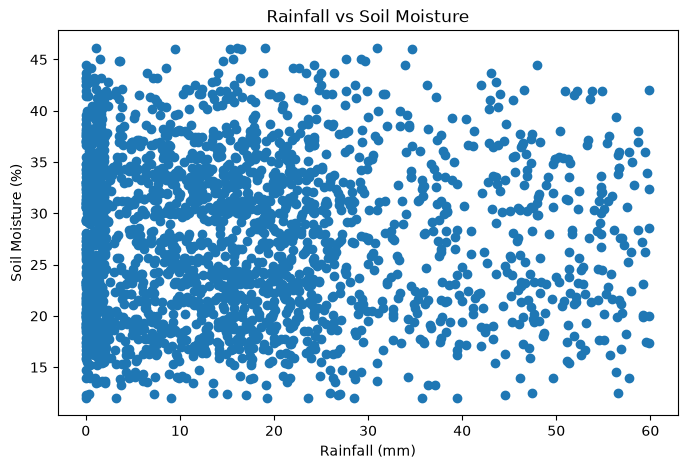

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    master_df["Rainfall_mm"],
    master_df["Soil_Moisture_Percent"]
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Soil Moisture (%)")
plt.title("Rainfall vs Soil Moisture")

plt.show()

## Visualizing Rainfall Distribution

This histogram shows how the rainfall values are distributed in our dataset.

The X-axis represents rainfall in millimeters, while the Y-axis represents
how many records fall within each rainfall range.

We are using this to understand whether most observations have low,
medium, or high rainfall before deciding how to define prototype risk.

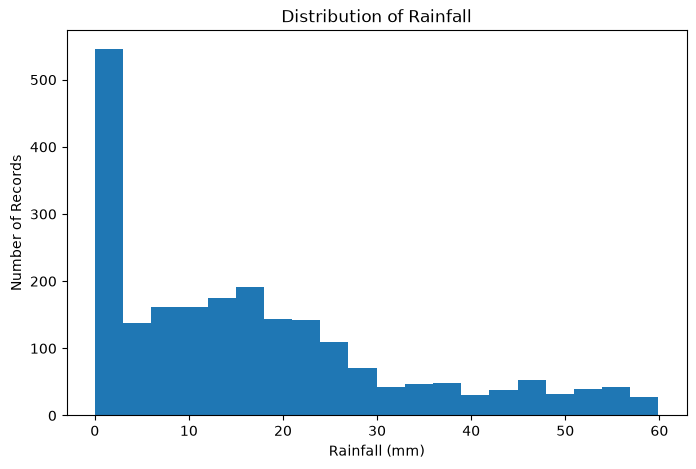

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(master_df["Rainfall_mm"], bins=20)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Number of Records")
plt.title("Distribution of Rainfall")

plt.show()

## Rainfall Percentiles

Percentiles help us understand the distribution of rainfall values.

- 10th percentile: about 10% of records have rainfall at or below this value.
- 25th percentile: about 25% of records have rainfall at or below this value.
- 50th percentile: the median rainfall.
- 75th percentile: about 75% of records have rainfall at or below this value.
- 90th percentile: about 90% of records have rainfall at or below this value.

We will use these values to understand what counts as relatively low
or relatively high rainfall in our dataset.

In [26]:
rainfall_percentiles = master_df["Rainfall_mm"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

rainfall_percentiles

0.10     0.600
0.25     3.300
0.50    14.000
0.75    24.225
0.90    42.510
Name: Rainfall_mm, dtype: float64

## Soil Moisture Percentiles

We will now examine the distribution of soil moisture using percentiles.

This helps us identify relatively low, typical, and relatively high
soil-moisture values in our dataset.

These values will help us evaluate whether our current prototype
thresholds of 20% and 35% are reasonable for this dataset.

In [27]:
soil_moisture_percentiles = master_df["Soil_Moisture_Percent"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

soil_moisture_percentiles

0.10    17.606
0.25    21.390
0.50    27.640
0.75    33.695
0.90    37.962
Name: Soil_Moisture_Percent, dtype: float64

## Creating the Prototype Risk Category

Our Risk_Score is a numerical value calculated using our prototype
rule-based conditions.

We will convert the score into three categories:

- 0–19 → Low Risk
- 20–39 → Moderate Risk
- 40 or more → High Risk

This Risk_Category will later act as our prototype target variable.

Important:
This is NOT a real-world disease label. It is a synthetic target
created from our own rules for learning how supervised Machine Learning works.

In [28]:
def risk_category(score):
    if score < 20:
        return "Low"
    elif score < 40:
        return "Moderate"
    else:
        return "High"


master_df["Risk_Category"] = master_df["Risk_Score"].apply(risk_category)

master_df[
    ["Rainfall_mm", "Soil_Moisture_Percent", "Risk_Score", "Risk_Category"]
].head(10)

,Rainfall_mm,Soil_Moisture_Percent,Risk_Score,Risk_Category
0,23.8,34.04,20,Moderate
1,28.1,32.83,20,Moderate
2,25.1,34.34,20,Moderate
3,25.8,32.69,20,Moderate
4,34.6,33.50,20,Moderate
5,22.9,29.60,20,Moderate
6,1.7,30.75,20,Moderate
7,31.8,31.17,20,Moderate
8,17.0,29.96,0,Low
9,25.6,30.93,20,Moderate


## Distribution of the Prototype Risk Categories

We will count how many observations belong to each risk category.

This helps us check whether our target variable is reasonably balanced
or whether one category dominates the dataset.

A highly imbalanced target can affect Machine Learning model training.

In [30]:
risk_category_counts = master_df["Risk_Category"].value_counts()

risk_category_counts

Risk_Category
Moderate    1311
High         788
Low          141
Name: count, dtype: int64

## Separating Features (X) and Target (y)

In supervised Machine Learning, we separate our dataset into:

- X = input features used by the model
- y = target/output that the model should predict

For our first prototype model:

X will contain:
- Rainfall_mm
- Soil_Moisture_Percent

y will contain:
- Risk_Category

The model will learn a relationship between X and y.

In [31]:
X = master_df[
    ["Rainfall_mm", "Soil_Moisture_Percent"]
]

y = master_df["Risk_Category"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X shape: (2240, 2)
y shape: (2240,)

Features:
   Rainfall_mm  Soil_Moisture_Percent
0         23.8                  34.04
1         28.1                  32.83
2         25.1                  34.34
3         25.8                  32.69
4         34.6                  33.50

Target:
0    Moderate
1    Moderate
2    Moderate
3    Moderate
4    Moderate
Name: Risk_Category, dtype: str


## Splitting Data into Training and Testing Sets

We will divide our data into two parts:

- Training data: used by the model to learn patterns.
- Testing data: kept separate and used to evaluate the model.

We will use 80% of the data for training and 20% for testing.

With 2,240 records, this gives approximately:

- 1,792 training records
- 448 testing records

The test data should not be used while training the model.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1792, 2)
Testing features: (448, 2)
Training target: (1792,)
Testing target: (448,)


## Checking the Training and Testing Target Distribution

We will compare the risk-category counts in the training and testing sets.

Because we used stratify=y, the proportions of Low, Moderate, and High
should remain approximately the same in both sets.

In [35]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Risk_Category
Moderate    1049
High         630
Low          113
Name: count, dtype: int64

Testing target distribution:
Risk_Category
Moderate    262
High        158
Low          28
Name: count, dtype: int64


## Training Our First Machine Learning Model

We will train a Decision Tree Classifier using the training data.

The model will learn patterns from:

- X_train → Rainfall and Soil Moisture
- y_train → Low, Moderate, or High Risk

The model does not receive the testing data during training.

After training, we will use X_test to see how well the model
predicts previously unseen records.

In [36]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


## Looking Inside Our Trained Decision Tree

The Decision Tree has now learned patterns from the training data.

We can check:

- **Tree depth** → how many levels of decisions the tree has.
- **Number of leaves** → how many final decision points the tree has.
- **Classes** → the risk categories the model learned to predict.

This helps us understand the complexity of our trained model.

In [37]:
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())
print("Classes learned by the model:", model.classes_)

Tree depth: 4
Number of leaves: 9
Classes learned by the model: ['High' 'Low' 'Moderate']


## Inspecting the Decision Tree's Learned Rules

Our Decision Tree learned decision rules from the training data.

Each internal node of the tree represents a question about a feature,
such as:

- Is Rainfall_mm less than a certain value?
- Is Soil_Moisture_Percent less than a certain value?

The tree uses these questions to eventually reach a leaf and predict
Low, Moderate, or High Risk.

We will inspect the tree structure to understand what the model actually learned.

In [38]:
from sklearn.tree import export_text

tree_rules = export_text(
    model,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- Soil_Moisture_Percent <= 34.96
|   |--- Soil_Moisture_Percent <= 20.01
|   |   |--- Rainfall_mm <= 14.95
|   |   |   |--- class: High
|   |   |--- Rainfall_mm >  14.95
|   |   |   |--- Rainfall_mm <= 19.00
|   |   |   |   |--- class: Moderate
|   |   |   |--- Rainfall_mm >  19.00
|   |   |   |   |--- class: High
|   |--- Soil_Moisture_Percent >  20.01
|   |   |--- Rainfall_mm <= 14.95
|   |   |   |--- class: Moderate
|   |   |--- Rainfall_mm >  14.95
|   |   |   |--- Rainfall_mm <= 19.05
|   |   |   |   |--- class: Low
|   |   |   |--- Rainfall_mm >  19.05
|   |   |   |   |--- class: Moderate
|--- Soil_Moisture_Percent >  34.96
|   |--- Rainfall_mm <= 15.05
|   |   |--- class: High
|   |--- Rainfall_mm >  15.05
|   |   |--- Rainfall_mm <= 19.00
|   |   |   |--- class: Moderate
|   |   |--- Rainfall_mm >  19.00
|   |   |   |--- class: High



## Making Predictions on Unseen Testing Data

The model was trained using only the training data.

Now we will give it the 448 testing records that it did NOT see during training.

The model will predict the risk category for each testing record.

We will store these predictions in `y_pred`.

Then we can compare:
- `y_test` → the actual risk category
- `y_pred` → the model's predicted risk category


This helps us evaluate how well the model learned.

In [39]:
y_pred = model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).to_list())

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
['Moderate', 'High', 'High', 'Moderate', 'High', 'Moderate', 'High', 'High', 'Low', 'Moderate']

First 10 predicted values:
['Moderate' 'High' 'High' 'Moderate' 'High' 'Moderate' 'High' 'High' 'Low'
 'Moderate']


## Comparing All Actual and Predicted Values

We have predictions for all 448 testing records.

Now we will compare `y_test` (actual answers)
with `y_pred` (model predictions).

This will tell us how many testing records the model predicted correctly.

In [40]:
correct_predictions = (y_test.to_numpy() == y_pred).sum()
total_predictions = len(y_test)

print("Correct predictions:", correct_predictions)
print("Total testing records:", total_predictions)

accuracy = correct_predictions / total_predictions

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Correct predictions: 448
Total testing records: 448
Accuracy: 1.0
Accuracy (%): 100.0


## Evaluating the Model with a Classification Report

Accuracy gives us one overall percentage.

A classification report gives us more detail about how the model
performs for each risk category:

- Low
- Moderate
- High

It reports precision, recall, F1-score, and support.

This helps us understand the model beyond overall accuracy.

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       158
         Low       1.00      1.00      1.00        28
    Moderate       1.00      1.00      1.00       262

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



## Creating a Confusion Matrix

A confusion matrix shows us how the model's predictions compare
with the actual risk categories.

It helps us see:

- Correct predictions
- Incorrect predictions
- Which risk categories were confused with each other

The rows represent the actual categories, while the columns
represent the model's predicted categories.

[[158   0   0]
 [  0  28   0]
 [  0   0 262]]


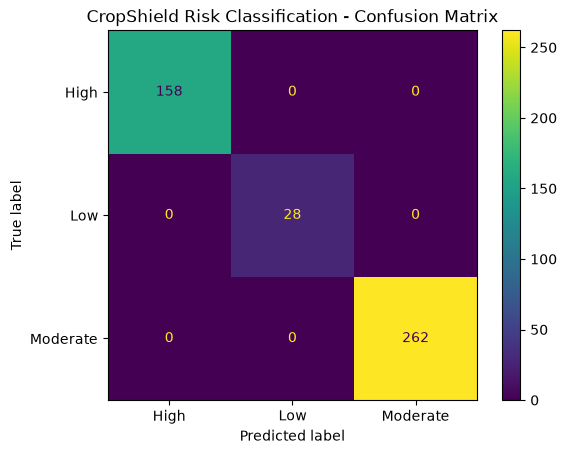

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("CropShield Risk Classification - Confusion Matrix")
plt.show()

## Feature Importance

Feature importance tells us how much each input feature contributed to the
Decision Tree's decisions.

Our current model uses:
- Rainfall_mm
- Soil_Moisture_Percent

The importance values are calculated by the trained model and should add up
to approximately 1.0.

In [43]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance

,Feature,Importance
0,Rainfall_mm,0.373498
1,Soil_Moisture_Percent,0.626502


## Saving the Trained Risk Prediction Model

The Decision Tree model has learned the relationship between rainfall,
soil moisture, and our prototype risk categories.

We save the trained model so that later the CropShield application
can load it and make predictions without training the model again.

In [44]:
import joblib

# Save the trained model
joblib.dump(model, "../models/risk_model.pkl")

print("Risk model saved successfully.")

Risk model saved successfully.


## Experiment: Adding More Environmental Features

In this experiment, we will add Temperature, Humidity, and Wind Speed
as extra features to our existing dataset.

These values are synthetic and are only for learning how the ML model
behaves when more features are available.

We will keep the original CSV unchanged.

In [45]:
import numpy as np

# Make the experiment reproducible
np.random.seed(42)

# Create a copy so the original dataset is not changed
experiment_df = master_df.copy()

# Add synthetic environmental features
experiment_df["Temperature_C"] = np.random.uniform(20, 35, len(experiment_df))
experiment_df["Humidity_Percent"] = np.random.uniform(40, 90, len(experiment_df))
experiment_df["Wind_Speed_kmph"] = np.random.uniform(5, 25, len(experiment_df))

# Check the new columns
experiment_df[[
    "Rainfall_mm",
    "Soil_Moisture_Percent",
    "Temperature_C",
    "Humidity_Percent",
    "Wind_Speed_kmph",
    "Risk_Category"
]].head()

,Rainfall_mm,Soil_Moisture_Percent,Temperature_C,Humidity_Percent,Wind_Speed_kmph,Risk_Category
0,23.8,34.04,25.618102,79.728914,8.229157,Moderate
1,28.1,32.83,34.260715,41.733513,14.434797,Moderate
2,25.1,34.34,30.979909,69.140342,16.069436,Moderate
3,25.8,32.69,28.979877,89.771876,16.405739,Moderate
4,34.6,33.50,22.340280,82.784805,9.202144,Moderate


## Training a Model with 5 Environmental Features

Here we train a new Decision Tree using rainfall, soil moisture,
temperature, humidity, and wind speed.

The target variable is still Risk_Category.

Because the three new features were generated randomly, we expect
the model to rely mainly on rainfall and soil moisture.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Input features
X_new = experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_kmph"
    ]
]

# Target variable
y_new = experiment_df["Risk_Category"]

# Split the data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.20,
    random_state=42,
    stratify=y_new
)

# Create and train the new model
model_new = DecisionTreeClassifier(random_state=42)
model_new.fit(X_train_new, y_train_new)

print("Training data:", X_train_new.shape)
print("Testing data:", X_test_new.shape)
print("Model trained successfully!")

Training data: (1792, 5)
Testing data: (448, 5)
Model trained successfully!


## Feature Importance

Feature importance tells us how much each feature contributed to the
Decision Tree's decisions.

A higher value means the model relied more on that feature when
splitting the data.

This does NOT mean the feature is scientifically responsible for
that percentage of the crop risk.

In [47]:
# Get feature importance from the trained model
importance = model_new.feature_importances_

# Create a table for easier understanding
feature_importance_df = pd.DataFrame({
    "Feature": X_new.columns,
    "Importance": importance
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
1,Soil_Moisture_Percent,0.626502
0,Rainfall_mm,0.373498
2,Temperature_C,0.000000
3,Humidity_Percent,0.000000
4,Wind_Speed_kmph,0.000000


## Comparing Model Performance

We will now calculate the accuracy of the new 5-feature model.

This helps us understand whether adding extra features actually
improved the model's predictions.

In [48]:
from sklearn.metrics import accuracy_score

# Make predictions using the new 5-feature model
y_pred_new = model_new.predict(X_test_new)

# Calculate accuracy
accuracy_new = accuracy_score(y_test_new, y_pred_new)

print("New model accuracy:", accuracy_new)
print("Accuracy percentage:", accuracy_new * 100, "%")

New model accuracy: 1.0
Accuracy percentage: 100.0 %


## Experiment: Making Temperature Relevant

Previously, Risk_Category depended only on rainfall and soil moisture.

Now we will create a new experimental risk score where temperature
also contributes to risk.

This is only for learning how a Machine Learning model responds when
a new feature actually contains information about the target.
The original dataset and CropShield risk logic remain unchanged.

In [49]:
# Make another copy for this experiment
temperature_experiment_df = experiment_df.copy()

# Start with the existing risk score
temperature_experiment_df["Experimental_Score"] = (
    temperature_experiment_df["Risk_Score"]
    if "Risk_Score" in temperature_experiment_df.columns
    else 0
)

# Add temperature-based risk
temperature_experiment_df.loc[
    temperature_experiment_df["Temperature_C"] > 32,
    "Experimental_Score"
] += 20

# Convert the experimental score into a category
def experimental_risk_category(score):
    if score < 20:
        return "Low"
    elif score < 40:
        return "Moderate"
    else:
        return "High"

temperature_experiment_df["Experimental_Risk_Category"] = (
    temperature_experiment_df["Experimental_Score"]
    .apply(experimental_risk_category)
)

# Check the result
temperature_experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Experimental_Score",
        "Experimental_Risk_Category"
    ]
].head(10)

,Rainfall_mm,Soil_Moisture_Percent,Temperature_C,Experimental_Score,Experimental_Risk_Category
0,23.8,34.04,25.618102,20,Moderate
1,28.1,32.83,34.260715,40,High
2,25.1,34.34,30.979909,20,Moderate
3,25.8,32.69,28.979877,20,Moderate
4,34.6,33.50,22.340280,20,Moderate
5,22.9,29.60,22.339918,20,Moderate
6,1.7,30.75,20.871254,20,Moderate
7,31.8,31.17,32.992642,40,High
8,17.0,29.96,29.016725,0,Low
9,25.6,30.93,30.621089,20,Moderate


## Training the Temperature-Aware Model

The experimental target now depends on temperature.

We will train a Decision Tree using all five environmental features
and check which features the model considers important.

This is only an experiment to understand Machine Learning behavior.
It is not part of the actual CropShield AI model.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Features
X_temp = temperature_experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_kmph"
    ]
]

# New experimental target
y_temp = temperature_experiment_df["Experimental_Risk_Category"]

# Split data into training and testing sets
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=y_temp
)

# Create and train the model
temperature_model = DecisionTreeClassifier(random_state=42)

temperature_model.fit(X_train_temp, y_train_temp)

print("Training data:", X_train_temp.shape)
print("Testing data:", X_test_temp.shape)
print("Model trained successfully!")

Training data: (1792, 5)
Testing data: (448, 5)
Model trained successfully!


## Feature Importance — Temperature Experiment

We will compare the importance of all five features.

Because temperature was deliberately included in our experimental
risk calculation, we expect the model to use Temperature_C as well.

In [51]:
# Get feature importance
temperature_importance = temperature_model.feature_importances_

# Put the results into a table
temperature_importance_df = pd.DataFrame({
    "Feature": X_temp.columns,
    "Importance": temperature_importance
})

# Sort from most important to least important
temperature_importance_df = temperature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

temperature_importance_df

,Feature,Importance
1,Soil_Moisture_Percent,0.517621
0,Rainfall_mm,0.307168
2,Temperature_C,0.175211
3,Humidity_Percent,0.000000
4,Wind_Speed_kmph,0.000000


In [52]:
# Make another copy for the humidity experiment
humidity_experiment_df = temperature_experiment_df.copy()

# Start with the previous experimental score
humidity_experiment_df["Humidity_Score"] = (
    humidity_experiment_df["Experimental_Score"]
)

# Add humidity-based risk
humidity_experiment_df.loc[
    humidity_experiment_df["Humidity_Percent"] > 80,
    "Humidity_Score"
] += 20

# Convert the new score into a risk category
humidity_experiment_df["Humidity_Risk_Category"] = (
    humidity_experiment_df["Humidity_Score"]
    .apply(experimental_risk_category)
)

# View the result
humidity_experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Humidity_Percent",
        "Humidity_Score",
        "Humidity_Risk_Category"
    ]
].head(10)

,Rainfall_mm,Soil_Moisture_Percent,Temperature_C,Humidity_Percent,Humidity_Score,Humidity_Risk_Category
0,23.8,34.04,25.618102,79.728914,20,Moderate
1,28.1,32.83,34.260715,41.733513,40,High
2,25.1,34.34,30.979909,69.140342,20,Moderate
3,25.8,32.69,28.979877,89.771876,40,High
4,34.6,33.50,22.340280,82.784805,40,High
5,22.9,29.60,22.339918,66.072284,20,Moderate
6,1.7,30.75,20.871254,43.182045,20,Moderate
7,31.8,31.17,32.992642,81.568676,60,High
8,17.0,29.96,29.016725,69.948925,0,Low
9,25.6,30.93,30.621089,45.746650,20,Moderate


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Features
X_humidity = humidity_experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_kmph"
    ]
]

# Target
y_humidity = humidity_experiment_df["Humidity_Risk_Category"]

# Split the data
X_train_humidity, X_test_humidity, y_train_humidity, y_test_humidity = train_test_split(
    X_humidity,
    y_humidity,
    test_size=0.20,
    random_state=42,
    stratify=y_humidity
)

# Train the model
humidity_model = DecisionTreeClassifier(random_state=42)

humidity_model.fit(
    X_train_humidity,
    y_train_humidity
)

print("Training data:", X_train_humidity.shape)
print("Testing data:", X_test_humidity.shape)
print("Model trained successfully!")

Training data: (1792, 5)
Testing data: (448, 5)
Model trained successfully!


In [54]:
# Get feature importance
humidity_importance = humidity_model.feature_importances_

# Create a table
humidity_importance_df = pd.DataFrame({
    "Feature": X_humidity.columns,
    "Importance": humidity_importance
})

# Sort from highest to lowest
humidity_importance_df = humidity_importance_df.sort_values(
    by="Importance",
    ascending=False
)

humidity_importance_df

,Feature,Importance
1,Soil_Moisture_Percent,0.462883
0,Rainfall_mm,0.262958
3,Humidity_Percent,0.145077
2,Temperature_C,0.124974
4,Wind_Speed_kmph,0.004109


In [55]:
wind_experiment_df = humidity_experiment_df.copy()

wind_experiment_df["Wind_Score"] = wind_experiment_df["Humidity_Score"]

wind_experiment_df.loc[
    wind_experiment_df["Wind_Speed_kmph"] > 20,
    "Wind_Score"
] += 20

wind_experiment_df["Wind_Risk_Category"] = (
    wind_experiment_df["Wind_Score"].apply(experimental_risk_category)
)

wind_experiment_df[
    [
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_kmph",
        "Wind_Score",
        "Wind_Risk_Category"
    ]
].head(10)

,Temperature_C,Humidity_Percent,Wind_Speed_kmph,Wind_Score,Wind_Risk_Category
0,25.618102,79.728914,8.229157,20,Moderate
1,34.260715,41.733513,14.434797,40,High
2,30.979909,69.140342,16.069436,20,Moderate
3,28.979877,89.771876,16.405739,40,High
4,22.340280,82.784805,9.202144,40,High
5,22.339918,66.072284,19.845428,20,Moderate
6,20.871254,43.182045,5.503982,20,Moderate
7,32.992642,81.568676,12.096637,60,High
8,29.016725,69.948925,20.604253,20,Moderate
9,30.621089,45.746650,16.277858,20,Moderate


In [56]:
X_wind = wind_experiment_df[
    [
        "Rainfall_mm",
        "Soil_Moisture_Percent",
        "Temperature_C",
        "Humidity_Percent",
        "Wind_Speed_kmph"
    ]
]

y_wind = wind_experiment_df["Wind_Risk_Category"]

X_train_wind, X_test_wind, y_train_wind, y_test_wind = train_test_split(
    X_wind,
    y_wind,
    test_size=0.20,
    random_state=42,
    stratify=y_wind
)

wind_model = DecisionTreeClassifier(random_state=42)

wind_model.fit(X_train_wind, y_train_wind)

print("Model trained successfully.")

Model trained successfully.


In [57]:
feature_importance_wind = pd.DataFrame({
    "Feature": X_wind.columns,
    "Importance": wind_model.feature_importances_
})

feature_importance_wind = feature_importance_wind.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_wind


,Feature,Importance
1,Soil_Moisture_Percent,0.290309
0,Rainfall_mm,0.222997
3,Humidity_Percent,0.197333
2,Temperature_C,0.179338
4,Wind_Speed_kmph,0.110023
